In [73]:
import pandas as pd
import numpy as np
# Load txt file
df = pd.read_csv(
    "/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt",
    sep=';',
    low_memory=False
)

# View first rows
print(df.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


In [74]:
import pandas as pd

# Combine Date and Time columns
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# Set datetime index
df.set_index('Datetime', inplace=True)

# Drop original columns
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Convert all columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check dataset
print(df.info())

print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None
                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00         

In [75]:
print(df.isnull().sum())

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


In [76]:
df.shape

(2075259, 7)

In [77]:
df = df.interpolate(method='time')

In [78]:
print(df.isnull().sum())

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [79]:
##Convert minute-level data into hourly-level data by taking:

##the average of all values within each hour.

In [80]:
hourly_df = df.resample('H').mean()

/tmp/ipykernel_57/3264399509.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.resample('H').mean()


In [81]:
hourly_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [82]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


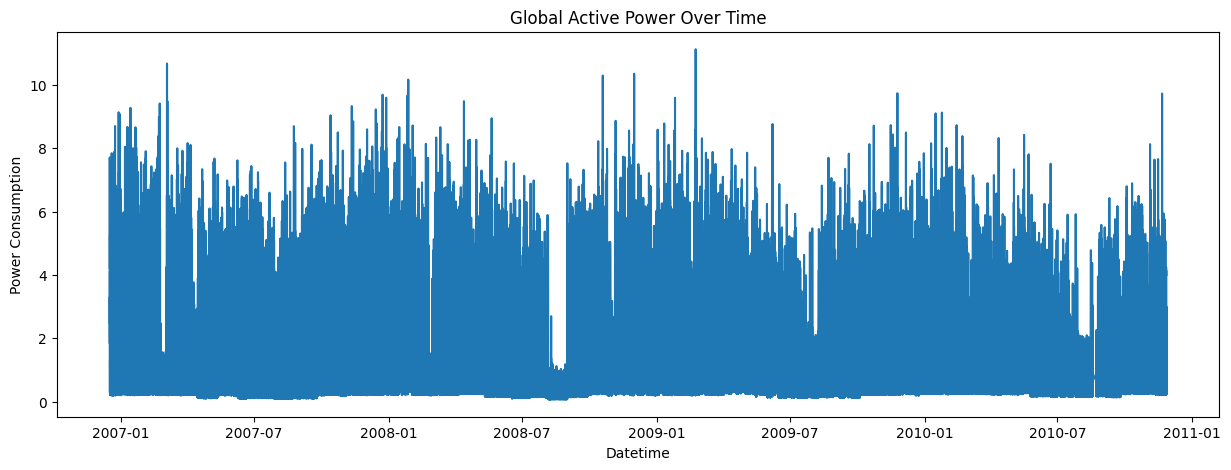

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df['Global_active_power'])

plt.title("Global Active Power Over Time")

plt.xlabel("Datetime")
plt.ylabel("Power Consumption")

plt.show()

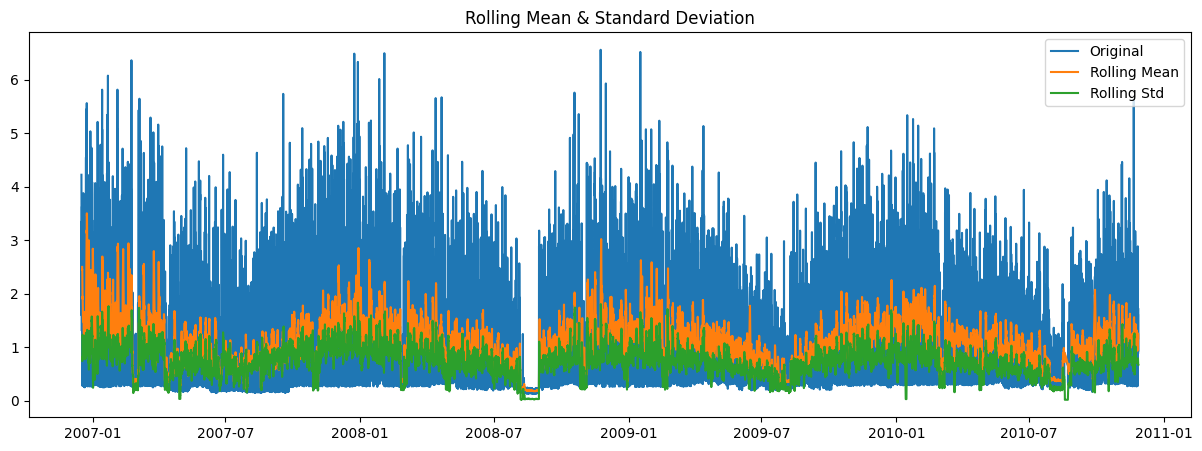

In [84]:
rolling_mean = hourly_df['Global_active_power'].rolling(window=24).mean()

rolling_std = hourly_df['Global_active_power'].rolling(window=24).std()

plt.figure(figsize=(15,5))

plt.plot(hourly_df['Global_active_power'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()

plt.title("Rolling Mean & Standard Deviation")

plt.show()

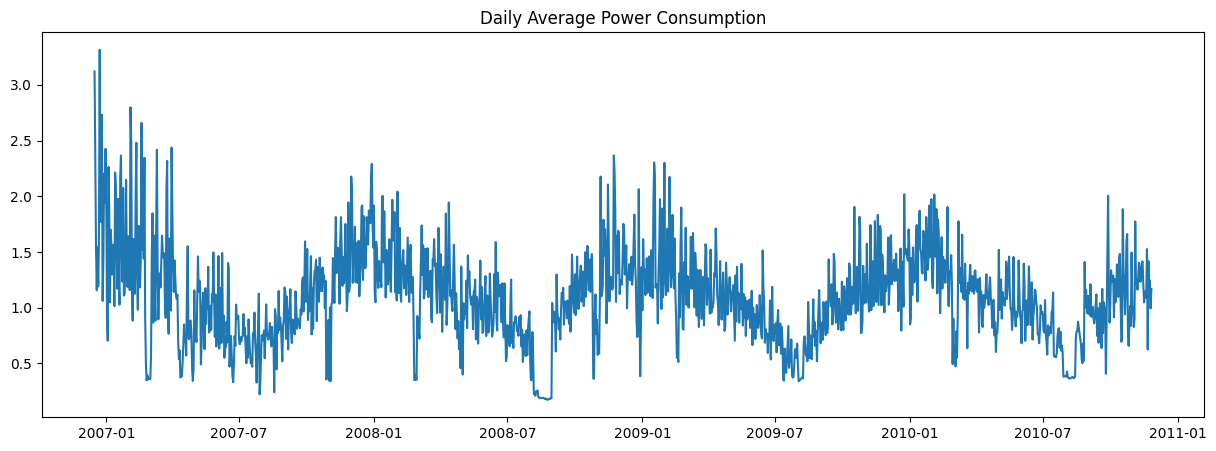

In [85]:
daily = hourly_df['Global_active_power'].resample('D').mean()

plt.figure(figsize=(15,5))

plt.plot(daily)

plt.title("Daily Average Power Consumption")

plt.show()

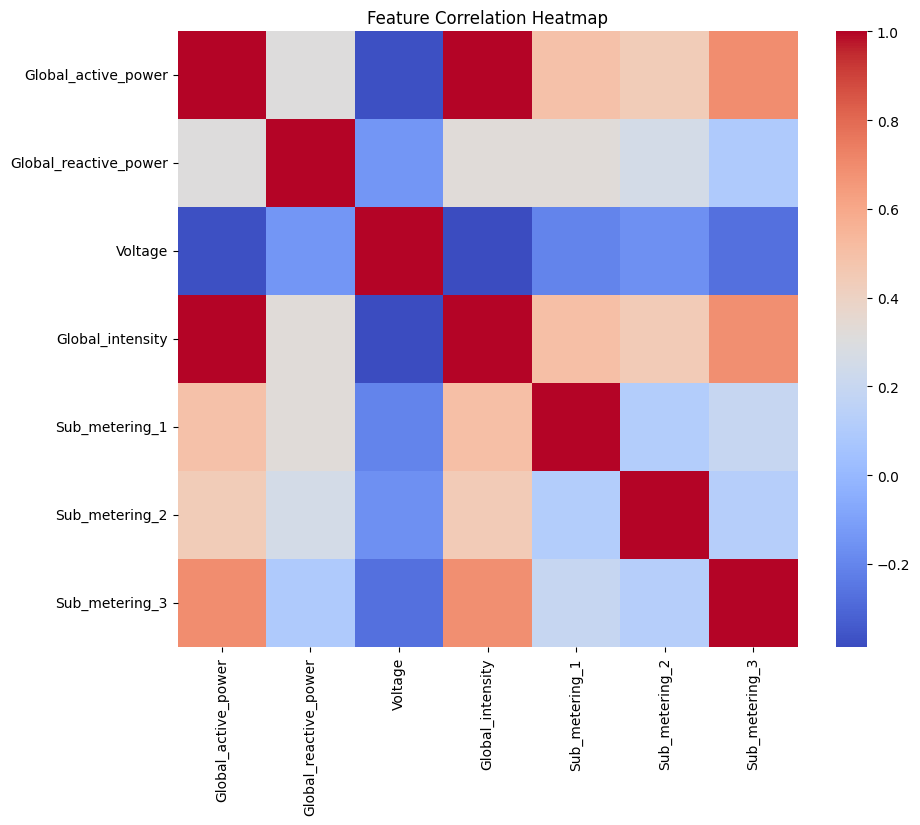

In [86]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(hourly_df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

In [87]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(hourly_df['Global_active_power'].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -14.371344689221528
p-value: 9.482687472631767e-27


In [88]:
hourly_df['lag_1'] = hourly_df['Global_active_power'].shift(1)

hourly_df['lag_24'] = hourly_df['Global_active_power'].shift(24)

hourly_df['lag_168'] = hourly_df['Global_active_power'].shift(168)


In [89]:
hourly_df['rolling_mean_24'] = (
    hourly_df['Global_active_power']
    .rolling(window=24)
    .mean()
)

hourly_df['rolling_std_24'] = (
    hourly_df['Global_active_power']
    .rolling(window=24)
    .std()
)

In [90]:
hourly_df['hour'] = hourly_df.index.hour

hourly_df['day'] = hourly_df.index.day

hourly_df['month'] = hourly_df.index.month

hourly_df['day_of_week'] = hourly_df.index.dayofweek

In [91]:
hourly_df.dropna(inplace=True)
hourly_df = hourly_df[:24*90]

In [92]:
target = hourly_df['Global_active_power']

train_size = int(len(target) * 0.8)

train = target[:train_size]
test = target[train_size:]

In [93]:
## AR MODEL

from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import numpy as np

ar_model = AutoReg(train, lags=24).fit()

ar_pred = ar_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

rmse_ar = np.sqrt(mean_squared_error(test, ar_pred))

print("AR RMSE:", rmse_ar)

AR RMSE: 1.032792034481514


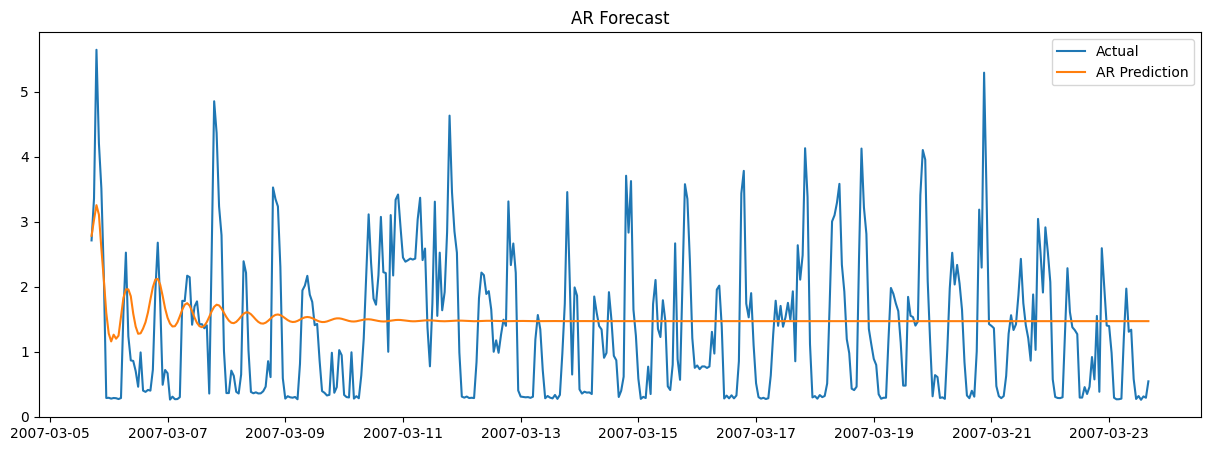

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, ar_pred, label='AR Prediction')

plt.legend()

plt.title("AR Forecast")

plt.show()

In [95]:
## MA Model

In [96]:
from statsmodels.tsa.arima.model import ARIMA

ma_model = ARIMA(train, order=(0,0,24)).fit()

ma_pred = ma_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

rmse_ma = np.sqrt(mean_squared_error(test, ma_pred))

print("MA RMSE:", rmse_ma)

MA RMSE: 1.0520189096735055


In [97]:
## ARIMA MODEL

In [98]:
arma_model = ARIMA(train, order=(24,0,24)).fit()

arma_pred = arma_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

rmse_arma = np.sqrt(mean_squared_error(test, arma_pred))

print("ARMA RMSE:", rmse_arma)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARMA RMSE: 0.9539629600638172


In [115]:
## ARIMA MODEL
arima_model = ARIMA(train, order=(24,0,24)).fit()

arima_pred = arima_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

rmse_arima = np.sqrt(mean_squared_error(test, arima_pred))

print("ARIMA RMSE:", rmse_arima)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA RMSE: 0.9539629600638172


In [99]:
## SARIMAX FUCNTION
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(2,0,2),
    seasonal_order=(1,1,1,24)
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [100]:
sarima_pred = sarima_model.predict(
    start=len(train),
    end=len(train)+len(test)-1
)

rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred))

print("SARIMA RMSE:", rmse_sarima)

SARIMA RMSE: 0.8091299980233044


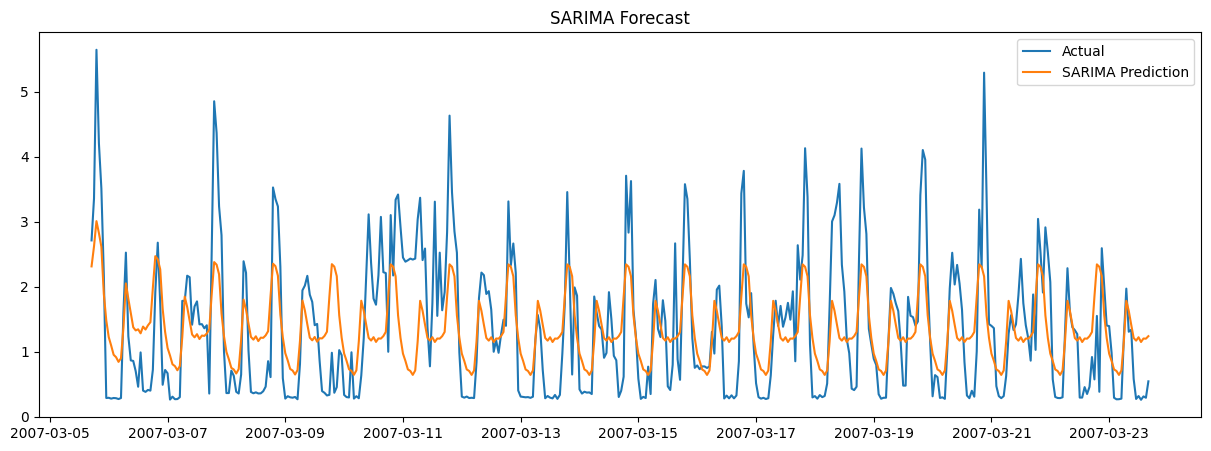

In [101]:
plt.figure(figsize=(15,5))

plt.plot(test.index, test, label='Actual')

plt.plot(test.index, sarima_pred, label='SARIMA Prediction')

plt.legend()

plt.title("SARIMA Forecast")

plt.show()

In [102]:
## Prophet Model

In [103]:
prophet_df = hourly_df.reset_index()[['Datetime', 'Global_active_power']]

prophet_df.columns = ['ds', 'y']

In [104]:
train_prophet = prophet_df[:train_size]

test_prophet = prophet_df[train_size:]

In [105]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

13:58:00 - cmdstanpy - INFO - Chain [1] start processing
13:58:00 - cmdstanpy - INFO - Chain [1] done processing


In [106]:
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq='H'
)

forecast = prophet_model.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [107]:
prophet_pred = forecast['yhat'][-len(test_prophet):].values

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet['y'],
        prophet_pred
    )
)

print("Prophet RMSE:", rmse_prophet)


Prophet RMSE: 1.5858508343886417


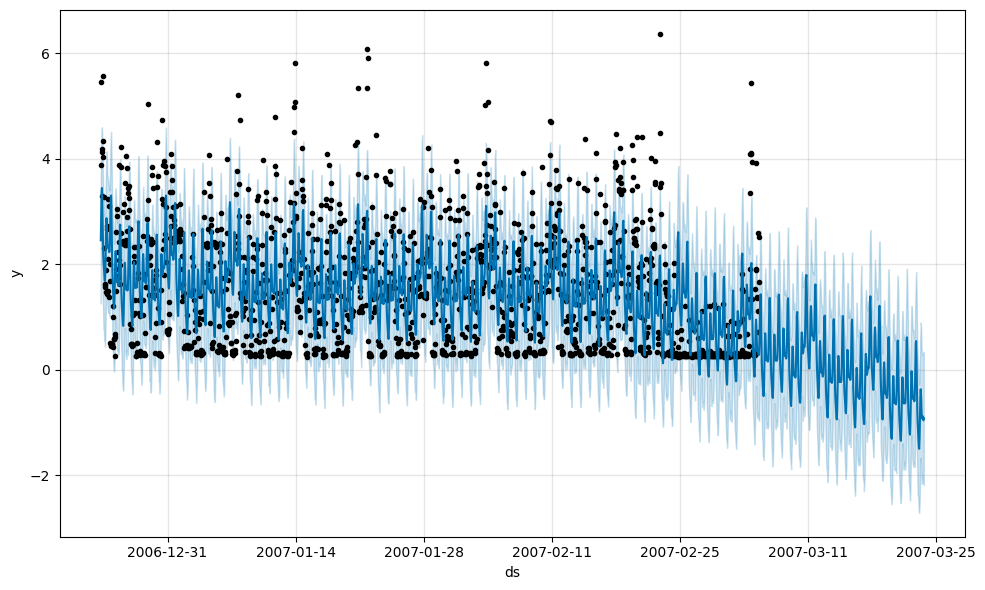

In [108]:
prophet_model.plot(forecast)
plt.show()

In [109]:
## XGBOOST Learning 
features = [
    'lag_1',
    'lag_24',
    'lag_168',
    'rolling_mean_24',
    'rolling_std_24',
    'hour',
    'day',
    'month',
    'day_of_week'
]

X = hourly_df[features]

y = hourly_df['Global_active_power']

In [110]:
X_train = X[:train_size]

X_test = X[train_size:]

y_train = y[:train_size]

y_test = y[train_size:]

In [111]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [112]:
xgb_pred = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_pred)
)

print("XGBoost RMSE:", rmse_xgb)

XGBoost RMSE: 0.6554911295136047


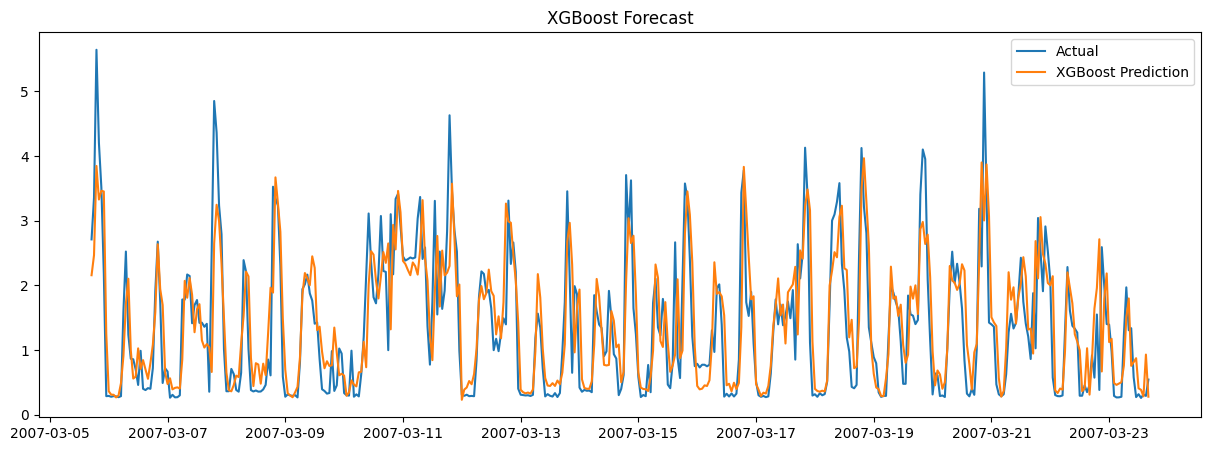

In [113]:
plt.figure(figsize=(15,5))

plt.plot(y_test.index, y_test, label='Actual')

plt.plot(y_test.index, xgb_pred, label='XGBoost Prediction')

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

In [120]:
results = {
    'Model': [
        'AR',
        'MA',
        'ARMA',
        'ARIMA',
        'SARIMA',
        'Prophet',
        'XGBoost'
    ],
    'RMSE': [
        rmse_ar,
        rmse_ma,
        rmse_arma,
        rmse_arima,
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ]
}

results_df = pd.DataFrame(results)

print(results_df.sort_values(by='RMSE'))

     Model      RMSE
6  XGBoost  0.655491
4   SARIMA  0.809130
3    ARIMA  0.953963
2     ARMA  0.953963
0       AR  1.032792
1       MA  1.052019
5  Prophet  1.585851


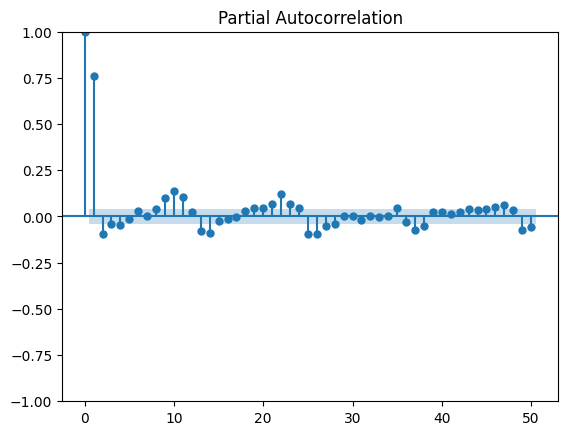

In [117]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(
    hourly_df['Global_active_power'].dropna(),
    lags=50
)

plt.show()

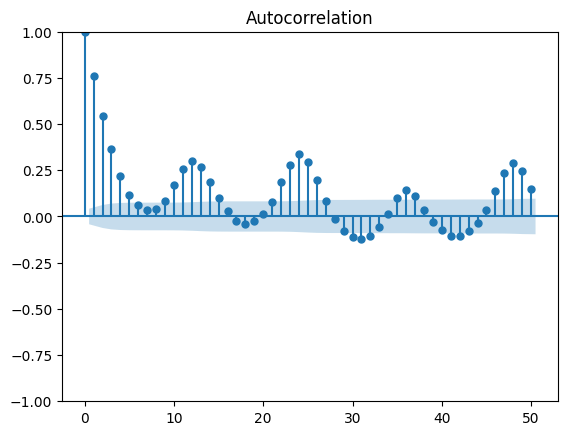

In [118]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    hourly_df['Global_active_power'].dropna(),
    lags=50
)

plt.show()

In [121]:
results_df = pd.DataFrame({
    'Category': [
        'Classical Statistical',
        'Classical Statistical',
        'Advanced Statistical',
        'Advanced Statistical',
        'Seasonal Statistical',
        'Modern Forecasting',
        'Machine Learning'
    ],
    
    'Model': [
        'AR',
        'MA',
        'ARMA',
        'ARIMA',
        'SARIMA',
        'Prophet',
        'XGBoost'
    ],
    
    'RMSE': [
        rmse_ar,
        rmse_ma,
        rmse_arma,
        rmse_arima,
        rmse_sarima,
        rmse_prophet,
        rmse_xgb
    ]
})

results_df = results_df.sort_values(by='RMSE')

print(results_df)

                Category    Model      RMSE
6       Machine Learning  XGBoost  0.655491
4   Seasonal Statistical   SARIMA  0.809130
3   Advanced Statistical    ARIMA  0.953963
2   Advanced Statistical     ARMA  0.953963
0  Classical Statistical       AR  1.032792
1  Classical Statistical       MA  1.052019
5     Modern Forecasting  Prophet  1.585851


In [122]:
residuals = y_test - xgb_pred

In [123]:
threshold = 2 * residuals.std()

In [124]:
anomalies = residuals[abs(residuals) > threshold]

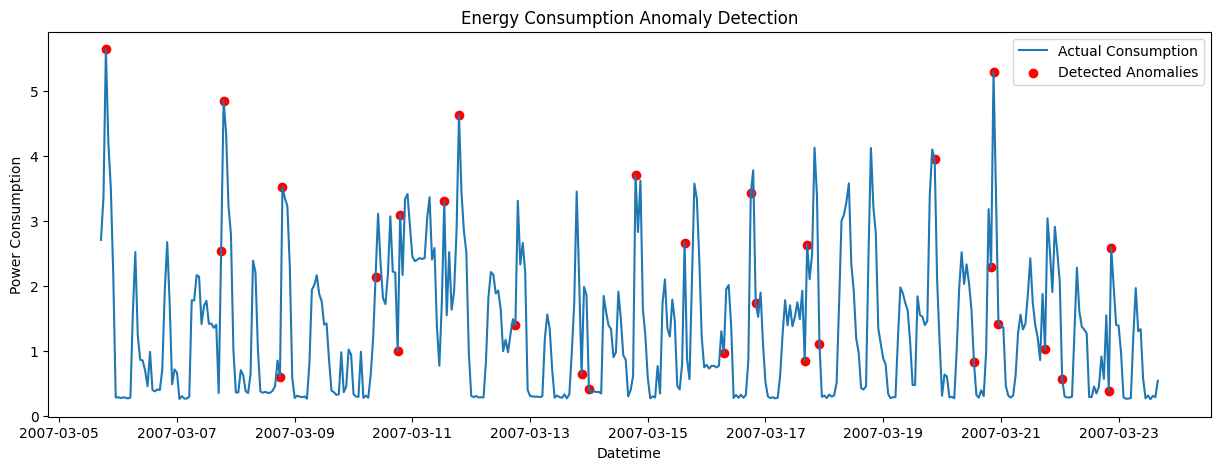

In [125]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    y_test.index,
    y_test,
    label='Actual Consumption'
)

plt.scatter(
    anomalies.index,
    y_test.loc[anomalies.index],
    color='red',
    label='Detected Anomalies'
)

plt.legend()

plt.title("Energy Consumption Anomaly Detection")

plt.xlabel("Datetime")

plt.ylabel("Power Consumption")

plt.show()

In [126]:
print("Total anomalies detected:", len(anomalies))

Total anomalies detected: 30


In [127]:
'''Threshold = 1.5

Detects:

moderate + strong anomalies.

Good for:

dashboards
visualization
monitoring systems.'''

'Threshold = 1.5\n\nDetects:\n\nmoderate + strong anomalies.\n\nGood for:\n\ndashboards\nvisualization\nmonitoring systems.'

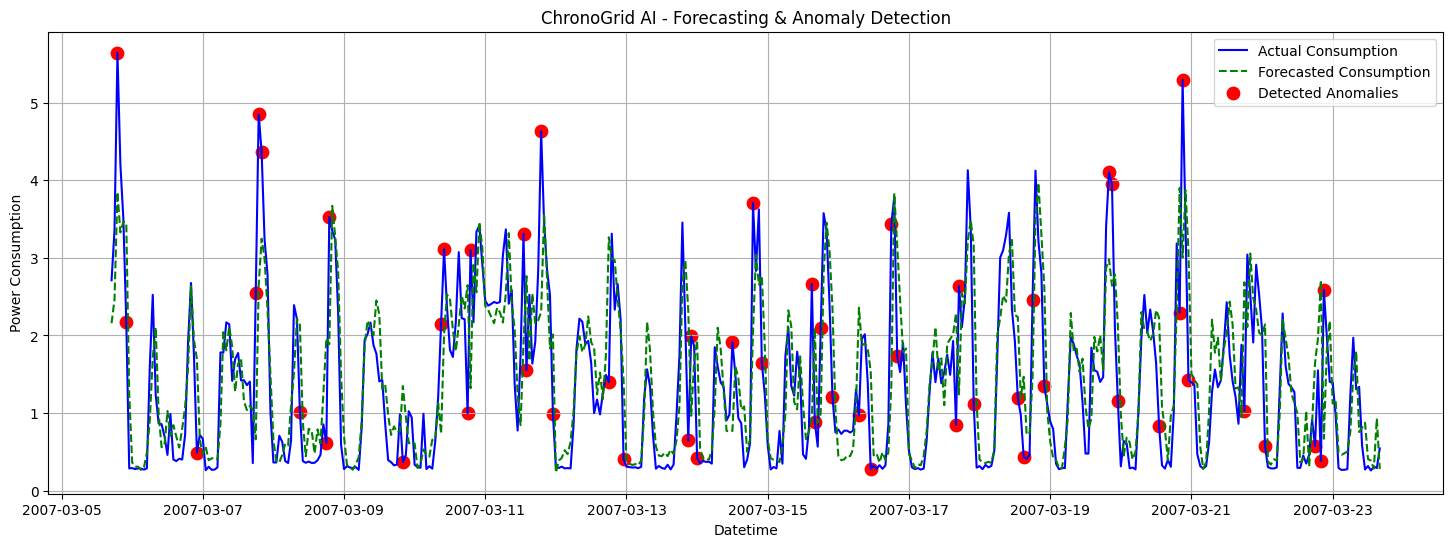

In [128]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test - xgb_pred

# Threshold
threshold = 1.5 * residuals.std()

# Detect anomalies
anomalies = residuals[abs(residuals) > threshold]

# Plot
plt.figure(figsize=(18,6))

# Original values
plt.plot(
    y_test.index,
    y_test,
    label='Actual Consumption',
    color='blue'
)

# Forecasted values
plt.plot(
    y_test.index,
    xgb_pred,
    label='Forecasted Consumption',
    color='green',
    linestyle='--'
)

# Anomaly points
plt.scatter(
    anomalies.index,
    y_test.loc[anomalies.index],
    color='red',
    s=80,
    label='Detected Anomalies'
)

plt.title(
    "ChronoGrid AI - Forecasting & Anomaly Detection"
)

plt.xlabel("Datetime")

plt.ylabel("Power Consumption")

plt.legend()

plt.grid(True)

plt.show()

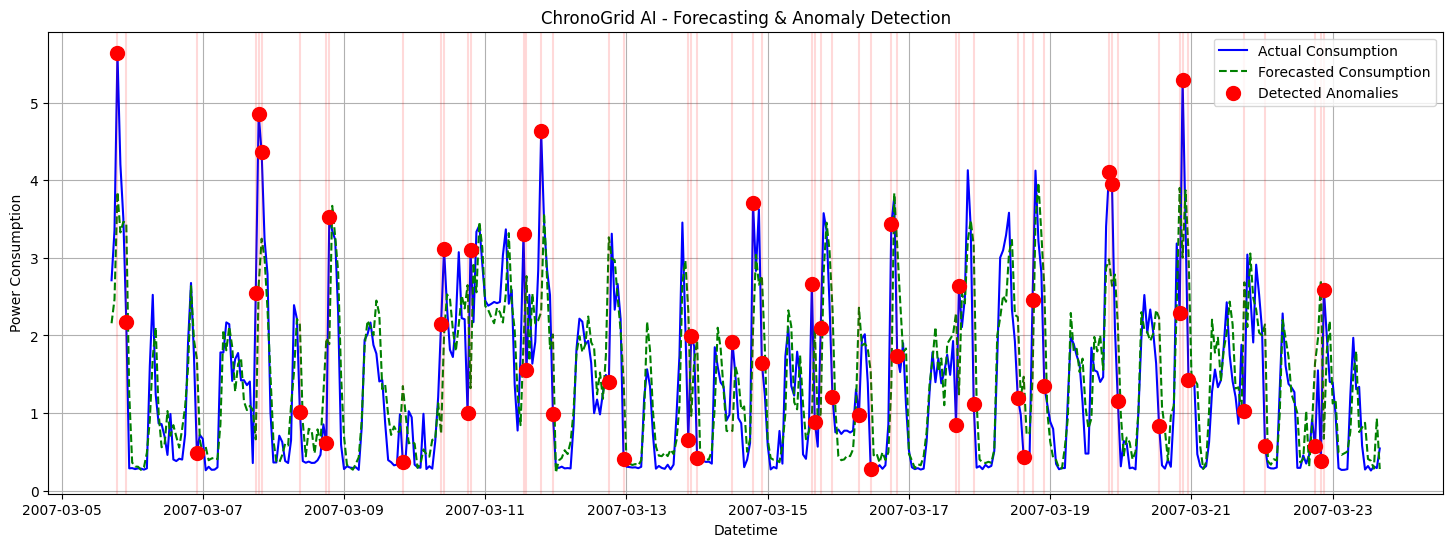

In [129]:
plt.figure(figsize=(18,6))

# Actual values
plt.plot(
    y_test.index,
    y_test,
    label='Actual Consumption',
    color='blue'
)

# Forecasted values
plt.plot(
    y_test.index,
    xgb_pred,
    label='Forecasted Consumption',
    color='green',
    linestyle='--'
)

# Anomaly points
plt.scatter(
    anomalies.index,
    y_test.loc[anomalies.index],
    color='red',
    s=100,
    label='Detected Anomalies',
    zorder=5
)

# Vertical anomaly markers
for idx in anomalies.index:
    plt.axvline(
        x=idx,
        color='red',
        alpha=0.15
    )

plt.title(
    "ChronoGrid AI - Forecasting & Anomaly Detection"
)

plt.xlabel("Datetime")
plt.ylabel("Power Consumption")

plt.legend()

plt.grid(True)

plt.show()

In [131]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [132]:
GROQ_API_KEY='your_groq_api_key'

In [133]:
from groq import Groq

In [134]:
client = Groq(
    api_key=GROQ_API_KEY
)

In [135]:
best_model = results_df.iloc[0]['Model']

best_rmse = results_df.iloc[0]['RMSE']

total_anomalies = len(anomalies)

peak_usage = y_test.max()

avg_usage = y_test.mean()

In [137]:
prompt = f"""
You are an AI-powered smart energy analytics assistant.

Analyze the following forecasting and anomaly detection results.

Forecasting Results:
- Best Forecasting Model: {best_model}
- Best RMSE: {best_rmse:.3f}

Energy Insights:
- Peak Energy Consumption: {peak_usage:.2f} kW
- Average Energy Consumption: {avg_usage:.2f} kW

Anomaly Detection:
- Total anomalies detected: {total_anomalies}

Generate:
1. Forecasting insights
2. Energy consumption insights
3. Anomaly detection insights
4. Overall system behavior summary

Keep the response professional and concise.
"""

In [139]:
response = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    
    temperature=0.5
)

In [140]:
ai_insights = response.choices[0].message.content

print(ai_insights)

**1. Forecasting Insights**  
- **Model Selection:** XGBoost emerged as the top‑performing algorithm, indicating that non‑linear relationships and feature interactions are important in the load‑profile data.  
- **Accuracy Metric:** An RMSE of **0.655 kW** reflects a relatively low average deviation between predicted and actual consumption, suitable for short‑term (hourly/daily) planning.  
- **Implications:** Forecasts can be trusted for routine scheduling (e.g., demand‑response dispatch) but may require refinement for extreme events (peak spikes). Consider augmenting the model with weather or occupancy variables to push RMSE below 0.5 kW.

**2. Energy Consumption Insights**  
- **Peak Load:** **5.64 kW** – roughly 4.1 × the average load, indicating occasional high‑intensity periods (likely HVAC, process start‑ups, or equipment cycles).  
- **Average Load:** **1.36 kW** – the baseline consumption that drives most of the energy cost.  
- **Load Factor:** \( \frac{\text{Average}}{\text{